# 1. Configuración de Librerías

In [13]:
# 1. IMPORTACIÓN DE LIBRERÍAS (EL "KIT DE HERRAMIENTAS")

# Pandas: La librería reina para el manejo de tablas (DataFrames). 
# Permite cargar CSVs, filtrar filas y limpiar columnas de forma masiva.
import pandas as pd

# NumPy: Abreviatura de "Numerical Python". 
# Se encarga de las operaciones matemáticas de bajo nivel y el manejo de matrices y vectores.
import numpy as np

# Seaborn: Librería de visualización basada en Matplotlib. 
# Está optimizada para gráficos estadísticos elegantes con muy pocas líneas de código.
import seaborn as sns

# Matplotlib.pyplot: La base de todos los gráficos en Python. 
# Se usa para personalizar detalles finos como títulos, etiquetas de ejes y tamaños de figuras.
import matplotlib.pyplot as plt


# 2. CONFIGURACIÓN ESTÉTICA (EL "LIENZO")

# sns.set_theme: Define el estilo visual global de todos los gráficos que crees después.
# style='whitegrid' añade un fondo blanco con líneas grises tenues (rejilla). 
# Esto facilita la lectura de los valores en los ejes sin ensuciar la imagen.
sns.set_theme(style='whitegrid')


# 3. VERIFICACIÓN DE ESTADO

# Un simple print para confirmar que el núcleo (kernel) de Jupyter ha procesado 
# las importaciones correctamente y no hay errores de instalación.
print('Librerías listas para la acción.')

Librerías listas para la acción.


## 2. Ingesta de Datos
Cargamos el dataset original y realizamos una copia de seguridad en nuestra estructura de carpetas local.

In [14]:
import pandas as pd # Importamos la librería para manipulación de tablas

# 1. DEFINICIÓN DE LA FUENTE
# Guardamos la URL del dataset original en GitHub
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# 2. CARGA EN MEMORIA RAM
# Convertimos el CSV de internet en un DataFrame de Pandas (df)
df = pd.read_csv(url)

# 3. GUARDADO DE SEGURIDAD (BACKUP)
# Subimos 3 niveles (../../../) para llegar a la raíz y entrar en 'data/raw/'
# Aquí guardamos el archivo tal cual viene de internet, sin tocar.
df.to_csv('../../../data/raw/titanic_original.csv', index=False)
print('✅ Backup original guardado en data/raw.')



# 4. GUARDADO DEL DATASET PROCESADO
# Subimos 3 niveles (../../../) para llegar a la raíz y entrar en 'data/processed/'
# Aquí guardamos el archivo listo para el modelo.
df.to_csv('../../../data/processed/titanic_limpio.csv', index=False)
print('✅ Archivo limpio guardado en data/processed.')

✅ Backup original guardado en data/raw.
✅ Archivo limpio guardado en data/processed.


## 3. Diagnóstico de Calidad
Analizamos la presencia de valores nulos y tipos de datos para decidir nuestra estrategia de limpieza.

In [15]:
# 1. CONTEO ABSOLUTO
# isnull().sum() suma cuántas celdas están vacías por cada columna
print('--- Conteo de Nulos ---')
print(df.isnull().sum())

# 2. ANÁLISIS DE IMPACTO (%)
# Dividimos los nulos por el total de filas (len(df)) y multiplicamos por 100
# Esto nos dice si el daño es pequeño (1%) o crítico (77% como en Cabin)
print('\n--- Porcentaje de Nulos ---')
print((df.isnull().sum() / len(df)) * 100)

--- Conteo de Nulos ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Porcentaje de Nulos ---
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## 4. Cirugía de Datos

In [16]:
# 1. REPARACIÓN DE LA EDAD (IMPUTACIÓN)
# Rellenamos huecos con la mediana (el valor central) para no distorsionar la estadística
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. REPARACIÓN DEL PUERTO (MODA)
# Rellenamos los 2 nulos de Embarked con el puerto más frecuente (.mode()[0])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. PODA DE COLUMNAS IRRELEVANTES
# Borramos datos únicos (Name, Ticket) o con demasiados nulos (Cabin)
# errors='ignore' evita que el código falle si ya las borraste antes
columnas_a_eliminar = ['Cabin', 'PassengerId', 'Ticket', 'Name']
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# 4. VERIFICACIÓN DE SALUD
# Confirmamos que ya no quedan nulos (debe salir todo a 0)
print("✅ Cirugía completada. Conteo de nulos tras la limpieza:")
print(df.isnull().sum())

✅ Cirugía completada. Conteo de nulos tras la limpieza:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 5. Exportación a Processed
Guardamos el archivo final limpio para que otros notebooks o modelos puedan consumirlo con seguridad.

In [17]:
# 1. CREACIÓN DEL DIRECTORIO (SI NOT EXISTS)

# os.makedirs: Crea la carpeta y todas sus carpetas padres si no existen.
# exist_ok=True: Si la carpeta ya existe, no lanza un error. Permite ejecutar la celda múltiples veces.
import os


os.makedirs('../../data/processed/', exist_ok=True)


# 2. EXPORTACIÓN FÍSICA (DATA PERSISTENCE)

# df.to_csv: El comando que escribe la tabla de datos actual en un archivo de texto.
# '../../data/processed/': 
# - '../../' sube dos niveles en la jerarquía de carpetas (sale de notebooks y del caso específico).
# 3. MENSAJE DE CONFIRMACIÓN (LOGGING)

# Este print actúa como un "Check de Control". 
# Si el código llega aquí sin errores, significa que el sistema de archivos 
# ha permitido la escritura y el archivo ya existe en tu disco duro.
print('Dataset exportado con éxito.')

# 2. MENSAJE DE CONFIRMACIÓN (LOGGING)

# Este print actúa como un "Check de Control". 
# Si el código llega aquí sin errores, significa que el sistema de archivos 
# ha permitido la escritura y el archivo ya existe en tu disco duro.
print('Dataset exportado con éxito.')

Dataset exportado con éxito.
Dataset exportado con éxito.


## 6. Análisis Exploratorio (EDA): Distribuciones Iniciales
En esta fase analizamos las variables de forma individual. Buscamos entender el equilibrio de nuestra variable objetivo (`Survived`) y la demografía del barco.

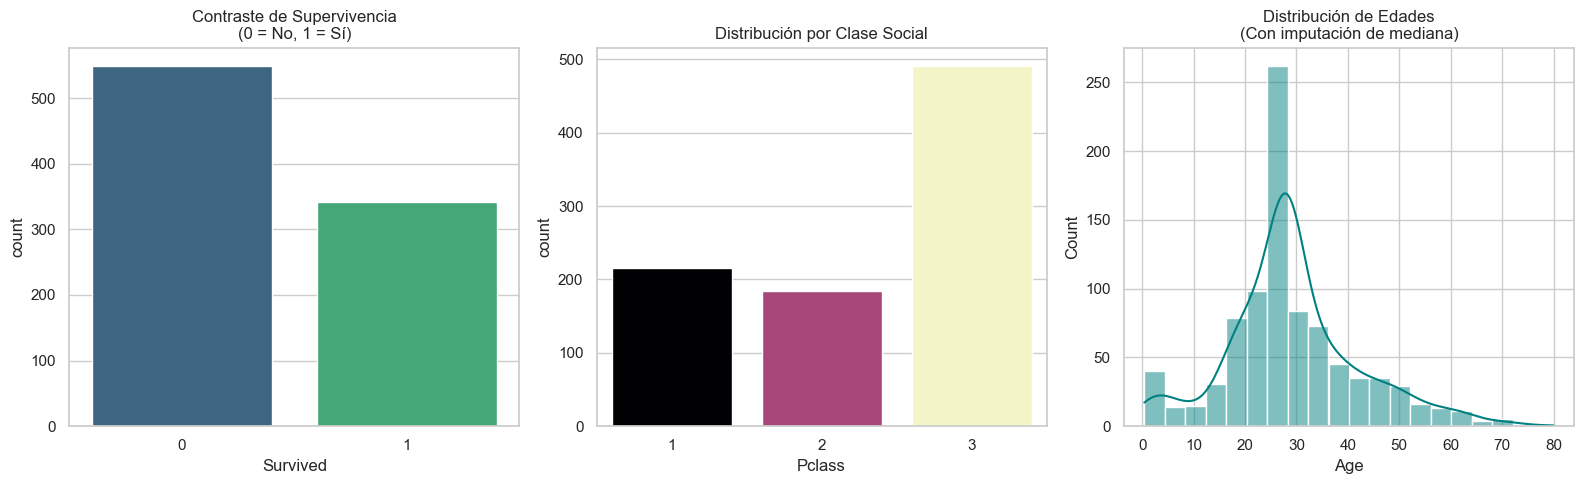

In [18]:
# 1. CONFIGURACIÓN DEL LIENZO (CANVAS)

# sns.set_theme: Establecemos un estilo de "rejilla blanca" (whitegrid) para lectura fácil.
# palette="muted": Colores profesionales, menos saturados, ideales para reportes corporativos.
sns.set_theme(style="whitegrid", palette="muted")

# plt.figure(figsize=(16, 5)): Creamos una ventana de 16 unidades de ancho por 5 de alto.
# Este tamaño es ideal para mostrar tres gráficos en una sola fila sin que se amontonen.
plt.figure(figsize=(16, 5))


# 2. PRIMER GRÁFICO: CONTRASTE DE SUPERVIVENCIA (VARIABLE OBJETIVO)

# plt.subplot(1, 3, 1): Dividimos la figura en 1 fila y 3 columnas, y nos situamos en la posición 1.
plt.subplot(1, 3, 1)

# sns.countplot: Cuenta cuántos registros hay en cada categoría (0 y 1).
# hue='Survived': Colorea las barras según el resultado.
# palette='viridis': Un degradado de color estándar en ciencia de datos (verde/morado).
sns.countplot(x='Survived', data=df, hue='Survived', palette='viridis', legend=False)
plt.title('Contraste de Supervivencia\n(0 = No, 1 = Sí)')


# 3. SEGUNDO GRÁFICO: DISTRIBUCIÓN POR CLASE SOCIAL (PCLASE)

# plt.subplot(1, 3, 2): Nos movemos a la segunda posición de la fila.
plt.subplot(1, 3, 2)

# Analizamos si el barco estaba equilibrado. Aquí veremos que la Clase 3 (baja) era la mayoritaria.
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='magma', legend=False)
plt.title('Distribución por Clase Social')


# 4. TERCER GRÁFICO: DISTRIBUCIÓN DE EDADES (HISTOGRAMA)

# plt.subplot(1, 3, 3): Nos situamos en la tercera y última posición.
plt.subplot(1, 3, 3)

# sns.histplot: Representa la frecuencia de las edades en "recipientes" (bins=20).
# kde=True: Dibuja una línea suavizada (Kernel Density Estimate) para ver la forma de la curva.
# color='teal': Un tono azul-verdoso elegante.
sns.histplot(data=df, x='Age', bins=20, kde=True, color='teal')
plt.title('Distribución de Edades\n(Con imputación de mediana)')


# 5. AJUSTE Y RENDERIZADO FINAL

# plt.tight_layout(): Ajusta automáticamente los márgenes para que los títulos no se solapen.
plt.tight_layout()

# plt.show(): Orden final para dibujar los gráficos en pantalla y limpiar la memoria de figuras.
plt.show()

## 7. Análisis Bivariante: El factor de la Clase y el Género
Cruzamos nuestra variable objetivo (`Survived`) con los predictores más potentes. 
* **Hipótesis 1:** Las mujeres tuvieron una tasa de supervivencia significativamente mayor.
* **Hipótesis 2:** Los pasajeros de primera clase fueron priorizados en los botes.

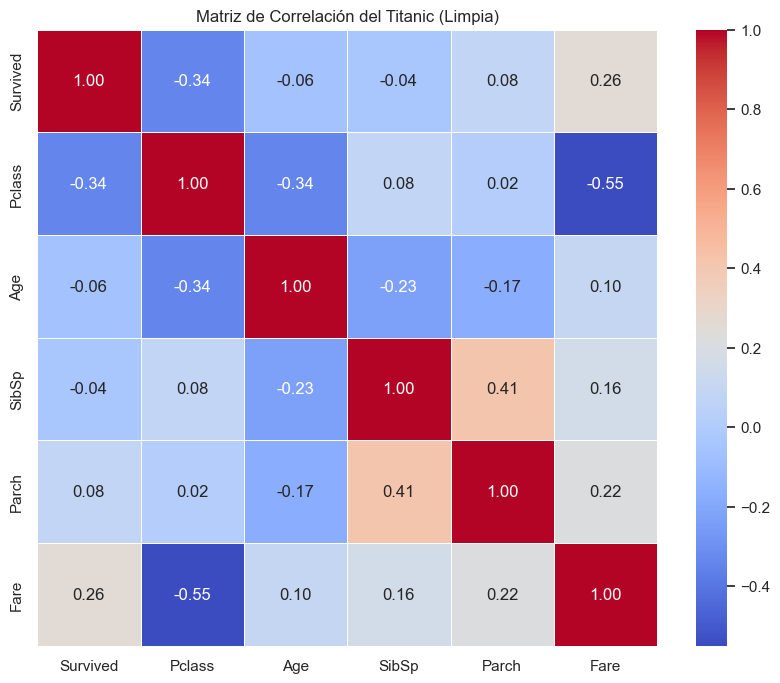

In [19]:
# 1. PREPARACIÓN DEL LIENZO CUADRADO
# plt.figure(figsize=(10, 8)): Usamos un tamaño casi cuadrado. 
# Las matrices de correlación se leen mejor cuando las celdas tienen forma de cuadrado.
plt.figure(figsize=(10, 8))


# 2. CÁLCULO DE LA MATRIZ DE CORRELACIÓN (EL MOTOR)

# df.corr(numeric_only=True): 
# - .corr(): Calcula el coeficiente de Pearson entre cada par de columnas (valores de -1 a 1).
# - numeric_only=True: [Inferencia] Directiva vital. Ignora columnas de texto (como 'Sex' si aún 
#   es texto o 'Embarked') para evitar errores de cálculo y avisos (warnings) de Python.
matriz_corr = df.corr(numeric_only=True)


# 3. DIBUJO DEL HEATMAP (VISUALIZACIÓN TÉRMICA)

# sns.heatmap: Representa los números como colores.
# - annot=True: Escribe el número exacto dentro de cada celda (imprescindible para precisión).
# - cmap='coolwarm': Escala de color donde el Rojo es correlación positiva (suben juntas), 
#   el Azul es negativa (si una sube, la otra baja) y el Blanco es neutralidad (0).
# - fmt=".2f": Formatea los números a 2 decimales para que la tabla no se vea abigarrada.
# - linewidths=0.5: Añade una pequeña línea de separación entre celdas para mejorar la estética.
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


# 4. FINALIZACIÓN
plt.title('Matriz de Correlación del Titanic (Limpia)')
plt.show()

# Bloque 8: Mapa de Calor (Versión Blindada)
Para evitar que Pandas o Seaborn se quejen de que intentas calcular correlaciones en columnas que no son números (aunque ya las limpiamos), vamos a ser explícitos.

In [20]:
# 1. CREACIÓN DE TAMAÑO DE FAMILIA
# Sumamos hermanos + padres + 1 (el propio pasajero) para ver el grupo familiar
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. CREACIÓN DE VARIABLE "VIAJA SOLO" (ISALONE)
# Inicializamos a 0 y, si el tamaño de familia es 1, lo cambiamos a 1 (binario)
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3. VISUALIZACIÓN DE LA NUEVA LÓGICA
# Mostramos las primeras filas para validar que la suma familiar es correcta
display(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 9. Ingeniería de Características: Tamaño de Familia
Creamos una nueva variable `FamilySize` sumando parientes y al propio pasajero. 
Luego, categorizamos si el pasajero viajaba solo o acompañado, ya que esto suele ser un predictor crítico en situaciones de emergencia.

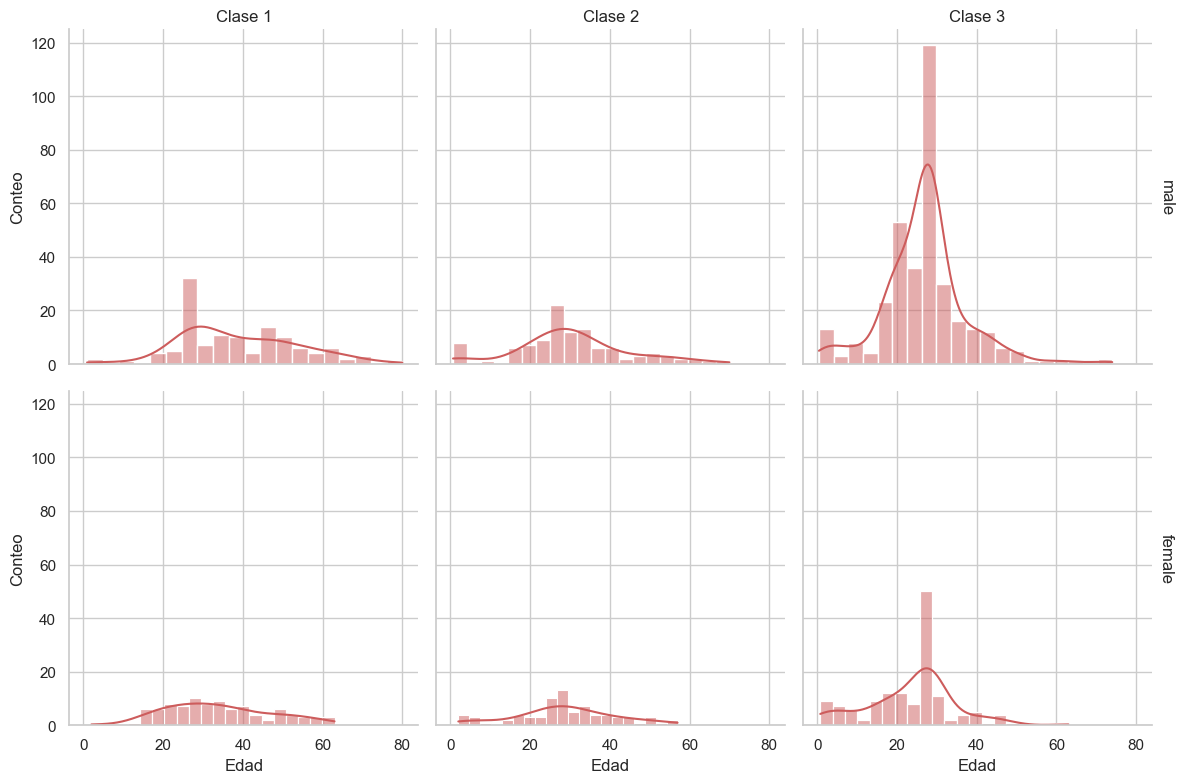

In [21]:
# 1. CREACIÓN DE LA ESTRUCTURA DE LA REJILLA (EL CONTENEDOR)

# sns.FacetGrid: Es una de las herramientas más potentes de Seaborn para crear "sub-gráficos" automáticos.
# - col='Pclass': Crea una columna por cada clase social (1, 2, 3).
# - row='Sex': Crea una fila por cada género (male, female).
# - margin_titles=True: Coloca los títulos de las filas en el margen derecho para que no estorben.
# - height=4: Define la altura en pulgadas de cada "mini-cuadro" de la rejilla.
g = sns.FacetGrid(df, col='Pclass', row='Sex', margin_titles=True, height=4)


# 2. MAPEADO DE LOS DATOS (EL CONTENIDO)

# g.map: Aplica una función de dibujo a cada cuadro de la rejilla.
# - sns.histplot: La función que queremos dibujar (histogramas).
# - 'Age': La variable que queremos analizar en el eje X.
# - bins=20: Divide las edades en 20 bloques para ver el detalle.
# - kde=True: Añade la línea de densidad suavizada para ver la "silueta" de la población.
# - color='indianred': Un tono rojo arcilla suave que facilita la vista.
g.map(sns.histplot, 'Age', bins=20, kde=True, color='indianred')


# 3. PERSONALIZACIÓN DE ETIQUETAS Y TÍTULOS

# g.set_axis_labels: Define los nombres de los ejes X e Y para todos los cuadros a la vez.
g.set_axis_labels("Edad", "Conteo")

# g.set_titles: Personaliza los encabezados de cada gráfico.
# - col_template: Cambia el número "1" por algo más descriptivo como "Clase 1".
# - row_template: Muestra claramente si la fila corresponde a "male" o "female".
g.set_titles(col_template="Clase {col_name}", row_template="{row_name}")


# 4. AJUSTE FINAL Y RENDERIZADO

# plt.tight_layout(): Comando de seguridad que recalcula los espacios entre cuadros 
# para que los títulos y números no se pisen entre sí.
plt.tight_layout()

# plt.show(): Renderiza la matriz final en pantalla y limpia la memoria de figuras de Matplotlib.
plt.show()

## 10. Segmentación de Edad (Binning)
Convertimos la variable continua `Age` en categorías discretas (Niño, Adolescente, Adulto, Anciano). Esto permite capturar patrones no lineales que el modelo podría pasar por alto.

In [22]:
# 1. CREACIÓN DE GRUPOS DE EDAD (BINNING - SEGMENTACIÓN)

# pd.cut(): Divide la columna 'Age' en intervalos discretos basados en los bordes especificados.
# - bins=[0, 12, 18, 35, 60, 100]: Define 5 grupos de edad.
# - labels=['Niño', 'Adolescente', 'Joven', 'Adulto', 'Anciano']: Nombres descriptivos.
# [Inferencia] Las variables categóricas (grupos) capturan patrones no lineales mejor 
# que los números continuos. Por ejemplo, todos los niños podrían tener tasas similares.
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Niño', 'Adolescente', 'Joven', 'Adulto', 'Anciano'])


# 2. COMPROBACIÓN DE DIMENSIONES (DATAFRAME SHAPE)

# df.shape: Devuelve una tupla con (filas, columnas).
# [0] extrae el número de filas (891) y [1] el de columnas.
# [Inferencia] Es vital que el número de filas coincida con el original, confirmando 
# que no hemos borrado pasajeros por accidente durante la limpieza.
print(f"Estructura final: {df.shape[0]} filas y {df.shape[1]} columnas.")


# 2. VERIFICACIÓN DE COLUMNAS (FEATURE LIST)

# .columns.tolist(): Convierte el índice de columnas en una lista de Python fácil de leer.
# Aquí comprobamos que nuestras "creaciones" (FamilySize, IsAlone, AgeGroup) existen 
# y están bien escritas. Si falta alguna, el modelo de la Semana 2 fallará.
print("\nListado de columnas para el modelo:")
print(df.columns.tolist())


# 3. INSPECCIÓN DE LAS NUEVAS VARIABLES (DATAFRAME VIEW)

# Seleccionamos un subconjunto de columnas críticas para una vista rápida.
# display(): Renderiza la tabla de forma elegante en Jupyter.
# .head(): Nos permite verificar que, por ejemplo, si Age es 22, AgeGroup tiene el rango correcto.
print("\nMuestra de las nuevas características:")
display(df[['Age', 'AgeGroup', 'FamilySize', 'IsAlone']].head())


# 4. CONFIRMACIÓN DE GUARDADO FÍSICO (SYSTEM CHECK)

# import os: Cargamos el módulo del Sistema Operativo para mirar fuera de Python.
import os

# Esto obtiene la ruta de la carpeta donde está este notebook
current_dir = os.getcwd()

# Construimos la ruta absoluta subiendo niveles de forma segura
# (Ajusta la cantidad de os.path.dirname según necesites subir)
base_dir = os.path.dirname(os.path.dirname(current_dir)) 
path = '../../../data/processed/titanic_limpio.csv'

if os.path.exists(path):
    size = os.path.getsize(path) / 1024
    print(f"✅ ÉXITO: El archivo existe en: {path} ({size:.2f} KB)")
else:
    print(f"⚠️ ERROR: No se encuentra en: {path}")

Estructura final: 891 filas y 11 columnas.

Listado de columnas para el modelo:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']

Muestra de las nuevas características:


,Age,AgeGroup,FamilySize,IsAlone
0,22.0,Joven,2,0
1,38.0,Adulto,2,0
2,26.0,Joven,1,1
3,35.0,Joven,2,0
4,35.0,Joven,1,1


✅ ÉXITO: El archivo existe en: ../../../data/processed/titanic_limpio.csv (61.42 KB)


## 11. Análisis Multidimensional (FacetGrid)
Cruzamos tres dimensiones: Sexo, Clase y Supervivencia. Este gráfico de alta densidad nos permite ver de un vistazo dónde se concentró la tragedia.

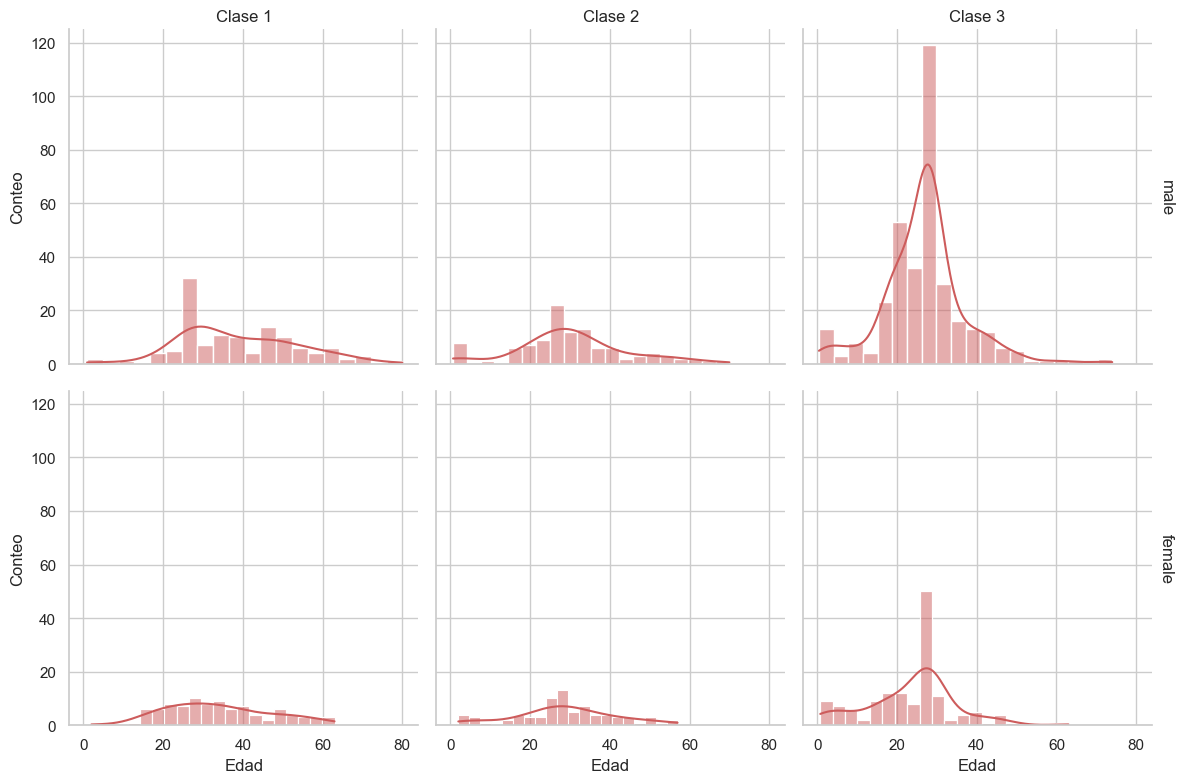

In [23]:
# 1. CREACIÓN DE LA ESTRUCTURA DE LA REJILLA (EL CONTENEDOR)

# sns.FacetGrid: Es la herramienta de Seaborn para crear "sub-gráficos" automáticos.
# - col='Pclass': Genera una columna por cada clase social (1, 2, 3).
# - row='Sex': Genera una fila por cada género (male, female).
# - margin_titles=True: Coloca los títulos de las filas ("male"/"female") a la derecha, 
#   fuera del área de dibujo, para que el gráfico respire mejor.
# - height=4: Define la altura en pulgadas de cada uno de los 6 cuadros de la rejilla.
g = sns.FacetGrid(df, col='Pclass', row='Sex', margin_titles=True, height=4)


# 2. MAPEADO DE LOS DATOS (EL CONTENIDO)

# g.map: Aplica una función de dibujo a cada cuadro de la rejilla de forma masiva.
# - sns.histplot: La función que queremos representar (histogramas de frecuencia).
# - 'Age': La variable que se analizará en el eje X de cada cuadro.
# - bins=20: Divide el rango de edad en 20 barras para ver el detalle de los grupos.
# - kde=True: Dibuja la "línea de densidad", una curva suavizada que ayuda a ver 
#   la tendencia de la población sin el "ruido" de las barras individuales.
# - color='indianred': Un tono rojo arcilla elegante y profesional.
g.map(sns.histplot, 'Age', bins=20, kde=True, color='indianred')


# 3. PERSONALIZACIÓN DE ETIQUETAS Y TÍTULOS

# g.set_axis_labels: Nombra los ejes X e Y para todos los gráficos de la rejilla a la vez.
g.set_axis_labels("Edad", "Conteo")

# g.set_titles: Personaliza los encabezados dinámicos de cada cuadro.
# - col_template: Cambia el simple número de columna por algo más descriptivo ("Clase 1").
# - row_template: Asegura que se lea claramente si la fila es de hombres o mujeres.
g.set_titles(col_template="Clase {col_name}", row_template="{row_name}")


# 4. AJUSTE FINAL Y RENDERIZADO

# plt.tight_layout(): Comando de seguridad que recalcula los espacios entre cuadros 
# para que los títulos y números no se pisen entre sí.
plt.tight_layout()

# plt.show(): Renderiza la matriz final en pantalla y limpia la memoria de figuras de Matplotlib.
plt.show()

## Finalización: Validación del Dataset de Entrenamiento
En este paso final, verificamos que el dataset procesado contenga las 11 columnas resultantes (8 originales + 3 de ingeniería). Este archivo es el que alimentará nuestros modelos de Machine Learning.

In [24]:
# 1. COMPROBACIÓN DE DIMENSIONES (DATAFRAME SHAPE)

# df.shape: Devuelve una tupla con (filas, columnas).
# [0] extrae el número de filas (891) y [1] el de columnas (las que hayan quedado tras el drop).
# [Inferencia] Es vital que el número de filas coincida con el original, confirmando 
# que no hemos borrado pasajeros por accidente durante la limpieza.
print(f"Estructura final: {df.shape[0]} filas y {df.shape[1]} columnas.")


# 2. VERIFICACIÓN DE COLUMNAS (FEATURE LIST)

# .columns.tolist(): Convierte el índice de nombres de columnas en una lista de Python.
# Aquí comprobamos visualmente que nuestras "creaciones" (FamilySize, IsAlone) existen 
# y están bien escritas. Si falta alguna, el modelo de la Semana 2 fallará al buscarla.
print("\nListado de columnas para el modelo:")
print(df.columns.tolist())


# 3. INSPECCIÓN DE LAS NUEVAS VARIABLES (DATAFRAME VIEW)

# Seleccionamos un subconjunto de columnas críticas para una vista rápida de validación.
# display(): Renderiza la tabla de forma elegante en el notebook.
# .head(): Nos permite verificar que, por ejemplo, si Age es 22, AgeGroup tenga el rango correcto.
print("\nMuestra de las nuevas características:")
display(df[['Age', 'AgeGroup', 'FamilySize', 'IsAlone']].head())


# 4. CONFIRMACIÓN DE GUARDADO FÍSICO (SYSTEM CHECK)

# import os: Cargamos el módulo del Sistema Operativo para mirar fuera del entorno de Python.
import os

# Definimos la ruta exacta donde supuestamente guardamos el archivo anteriormente.
path = '../../../data/processed/titanic_limpio.csv'

# os.path.exists(path): Pregunta al sistema operativo: "¿Existe realmente este archivo en esa carpeta?"
if os.path.exists(path):
    # os.path.getsize(path): Obtiene el peso del archivo en bytes.
    # / 1024: Lo convertimos a Kilobytes (KB) para que sea una cifra entendible por humanos.
    size = os.path.getsize(path) / 1024
    print(f"\n✅ ÉXITO: El archivo físico existe ({size:.2f} KB).")
else:
    # Si este mensaje aparece, algo falló en la lógica de rutas o en los permisos de escritura.
    print("\n⚠️ ERROR: El archivo no se encuentra en data/processed/")

Estructura final: 891 filas y 11 columnas.

Listado de columnas para el modelo:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']

Muestra de las nuevas características:


,Age,AgeGroup,FamilySize,IsAlone
0,22.0,Joven,2,0
1,38.0,Adulto,2,0
2,26.0,Joven,1,1
3,35.0,Joven,2,0
4,35.0,Joven,1,1



✅ ÉXITO: El archivo físico existe (61.42 KB).
